In [2]:
# multiple linear regression
# Multiple Linear Regression ek supervised learning algorithm hai jo multiple input features ko use karke ek continuous numerical value predict karta hai.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# dataset
data = {
    "Area_sqft": [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2200, 2400,
        2600, 2800, 3000, 3200, 3500
    ],

    "Bedrooms": [
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 4, 4, 4, 4,
        4, 5, 5, 5, 5
    ],

    "Bathrooms": [
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 4,
        4, 4, 4, 5, 5
    ],

    "Age_years": [
        20, 18, 15, 12, 10,
        8, 7, 6, 5, 5,
        4, 4, 3, 3, 2,
        2, 1, 1, 1, 0
    ],

    "Price_lakhs": [
        85, 92, 105, 115, 130,
        142, 150, 165, 178, 195,
        205, 220, 235, 260, 290,
        315, 345, 375, 410, 450
    ]
}

df = pd.DataFrame(data)

df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Price_lakhs
0,800,2,1,20,85
1,900,2,1,18,92
2,1000,2,2,15,105
3,1100,2,2,12,115
4,1200,3,2,10,130


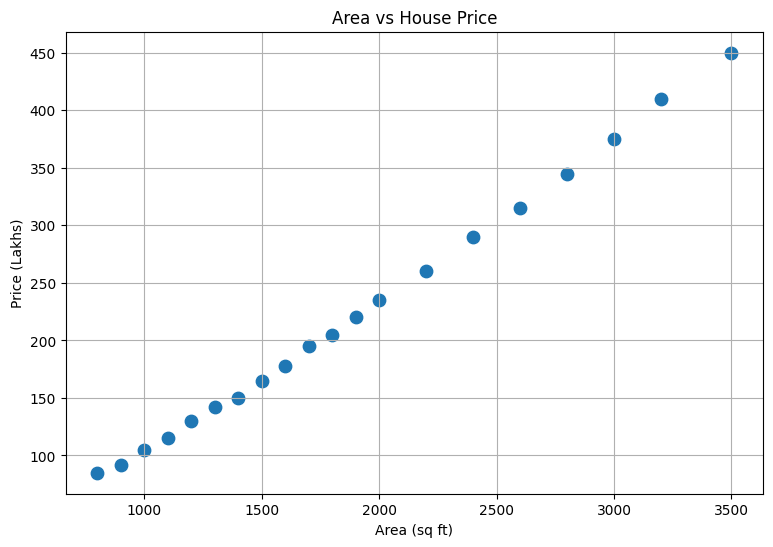

In [6]:
# visualize the data
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Area_sqft"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Area vs House Price")
plt.grid(True)

plt.show()

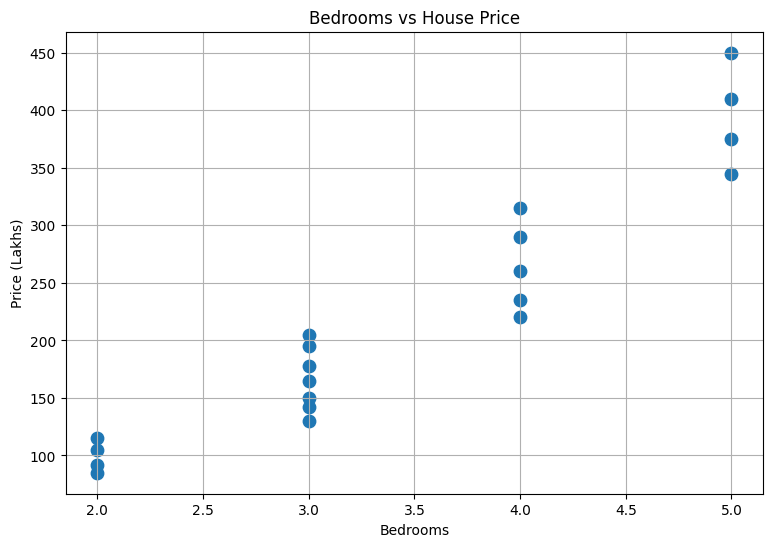

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Bedrooms"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Bedrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bedrooms vs House Price")
plt.grid(True)

plt.show()

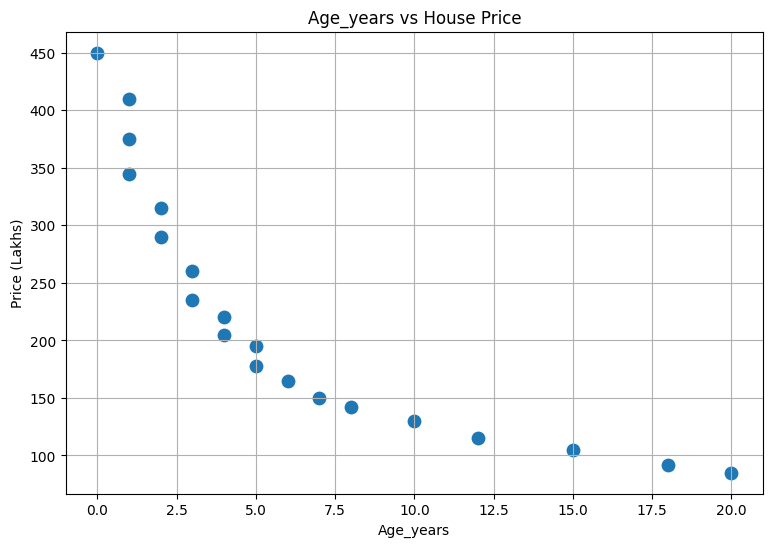

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Age_years"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Age_years")
plt.ylabel("Price (Lakhs)")
plt.title("Age_years vs House Price")
plt.grid(True)

plt.show()

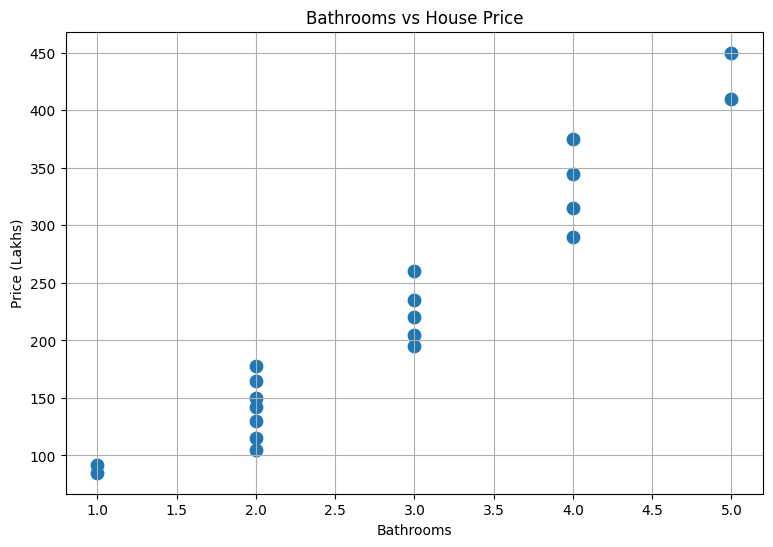

In [11]:
# visualize the data
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Bathrooms"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bathrooms vs House Price")
plt.grid(True)

plt.show()

In [13]:
# X and Y
X = df[
    [
        "Area_sqft",
        "Bedrooms",
        "Bathrooms",
        "Age_years"
    ]
]
y = df["Price_lakhs"]
# Ye Multiple Linear Regression ka core setup hai.


In [14]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# model
model = LinearRegression()

In [16]:
# train
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# model ne kya learn keya
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -66.91756753757056
Area_sqft : 0.14295023196963308
Bedrooms : 0.8127039445937001
Bathrooms : 2.2487513596306736
Age_years : 1.6302470643077571


In [ ]:
# Important: coefficients ko automatically "feature importance" mat samajhna. Different feature scales aur correlations ki wajah se raw coefficients directly compare karna misleading ho sakta hai.


In [18]:
# predictions
new_house = pd.DataFrame({
    "Area_sqft": [2000],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Age_years": [5]
})

prediction = model.predict(new_house)

print("Predicted Price:", prediction[0], "lakhs")

Predicted Price: 237.13120158050117 lakhs


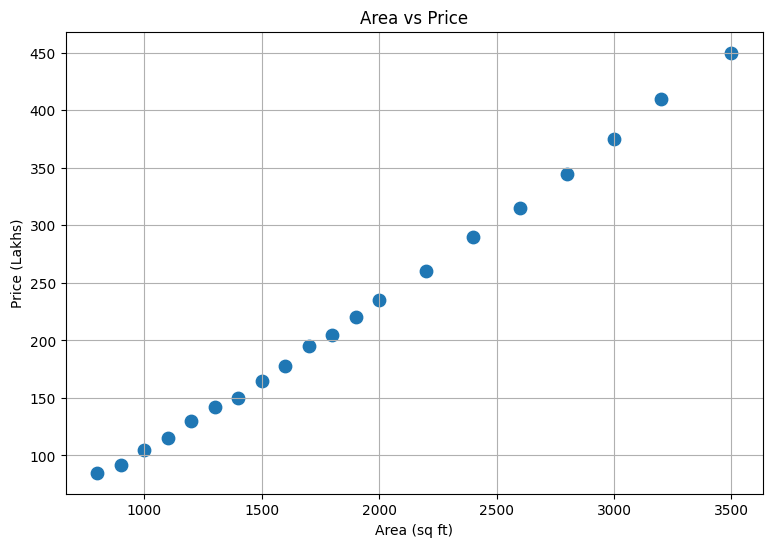

In [19]:
# graphs
# area vs price
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Area_sqft"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.title("Area vs Price")

plt.grid(True)
plt.show()

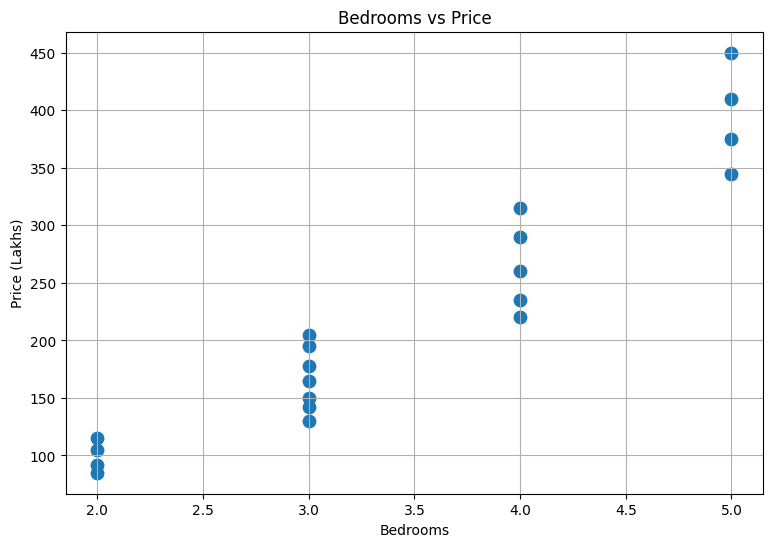

In [20]:
# bedroom vs price
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Bedrooms"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Bedrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bedrooms vs Price")

plt.grid(True)
plt.show()

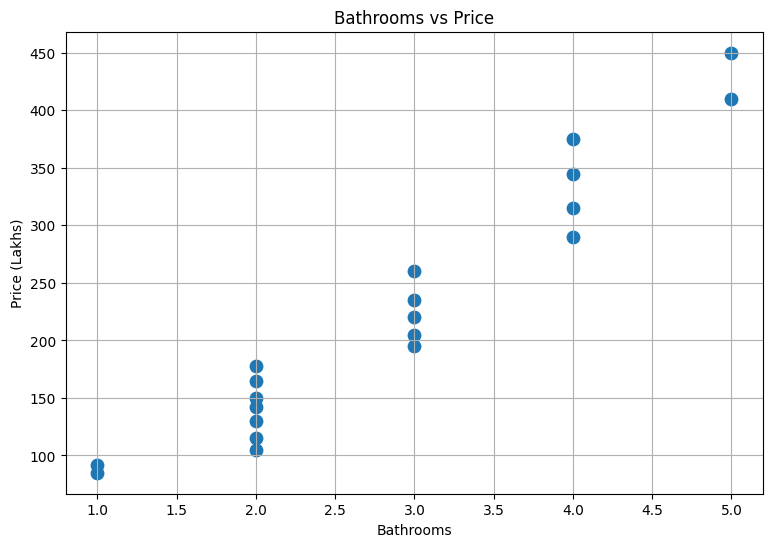

In [21]:
# bathroom vs price
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Bathrooms"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bathrooms vs Price")

plt.grid(True)
plt.show()

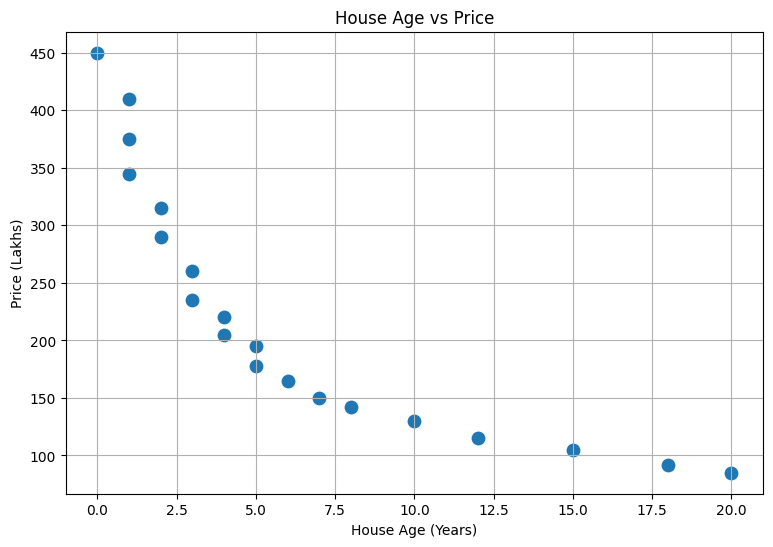

In [22]:
# age vs price
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Age_years"],
    df["Price_lakhs"],
    s=80
)

plt.xlabel("House Age (Years)")
plt.ylabel("Price (Lakhs)")
plt.title("House Age vs Price")

plt.grid(True)
plt.show()

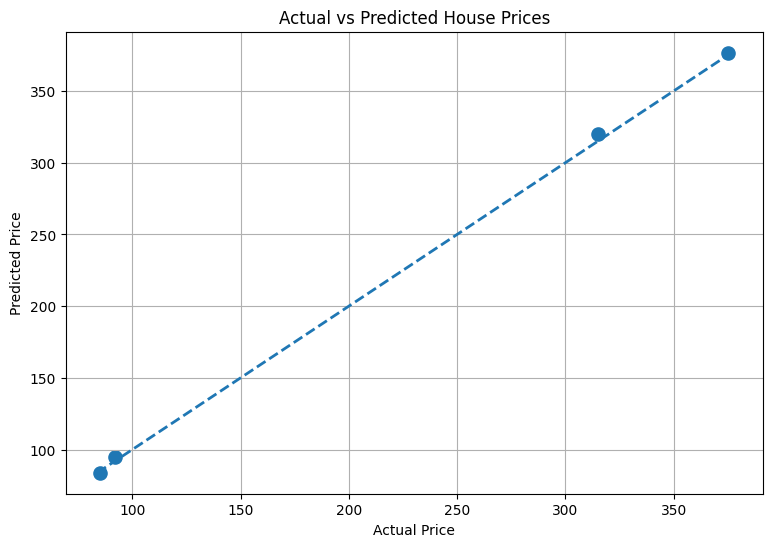

In [23]:
#actual vs predicted graph
y_pred = model.predict(X_test)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    s=90
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)
plt.show()

In [24]:
# metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.7289451486159706
RMSE: 3.1699142218052208
R²  : 0.9994055700001196
